# **2. EDA & VISUALISATIONS**

#### Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

#### Loading Dataset

In [2]:
df = pd.read_csv("./data/fraud_oracle.csv")
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


### Checking Target Variable

In [5]:
df["FraudFound_P"].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Plotting Pie Chart 

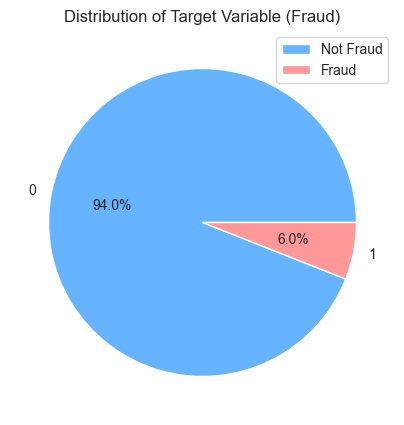

In [10]:
# Pie chart for target variable distribution
plt.figure(figsize=(5, 5))
df["FraudFound_P"].value_counts().plot.pie(autopct="%1.1f%%", colors=["#66b3ff", "#ff9999"])
plt.title("Distribution of Target Variable (Fraud)")
plt.legend(labels=["Not Fraud", "Fraud"], loc="upper right")
plt.show()

### Ordinal Columns

In [12]:
df.select_dtypes(include="object").columns.tolist()

['Month',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'DayOfWeekClaimed',
 'MonthClaimed',
 'Sex',
 'MaritalStatus',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'Days_Policy_Accident',
 'Days_Policy_Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange_Claim',
 'NumberOfCars',
 'BasePolicy']

In [52]:
cols_to_check = ["VehiclePrice", "Days_Policy_Accident", "Days_Policy_Claim", "PastNumberOfClaims", "AgeOfVehicle", "AgeOfPolicyHolder", "NumberOfCars", "NumberOfSuppliments", "AddressChange_Claim"]
for col in cols_to_check:
    print(f"======{col}======")
    print(df[col].value_counts())
    print("\n")

======VehiclePrice======
VehiclePrice
20000-30000    8079
30000-60000    3994
60000+         2251
<20000         1096
Name: count, dtype: int64


======Days_Policy_Accident======
Days_Policy_Accident
30+    15247
<30      173
Name: count, dtype: int64


======Days_Policy_Claim======
Days_Policy_Claim
30+    15342
<30       78
Name: count, dtype: int64


======PastNumberOfClaims======
PastNumberOfClaims
2-4    5485
0      4352
1      3573
4+     2010
Name: count, dtype: int64


======AgeOfVehicle======
AgeOfVehicle
7      5807
7+     3981
6      3448
2-5    1811
0       373
Name: count, dtype: int64


======AgeOfPolicyHolder======
AgeOfPolicyHolder
30-35    5593
35-40    4043
40-50    2828
50+      1900
21-30     721
16-20     335
Name: count, dtype: int64


======NumberOfCars======
NumberOfCars
1     14316
2+     1104
Name: count, dtype: int64


======NumberOfSuppliments======
NumberOfSuppliments
0      7047
5+     3867
1-2    2489
3-5    2017
Name: count, dtype: int64


======AddressC

##### Creating Appropriate Mapping for each

In [ ]:
df["VehiclePrice"] = df["VehiclePrice"].map(
    {
        "less than 20000": "<20000",
        "20000 to 29000": "20000-30000",
        "30000 to 39000": "30000-60000",
        "40000 to 59000": "30000-60000",
        "60000 to 69000": "60000+",
        "more than 69000": "60000+"
    }
)

df["Days_Policy_Accident"] = df["Days_Policy_Accident"].map(
    {
        "more than 30": "30+",
        "none": "<30",
        "8 to 15": "<30",
        "15 to 30": "<30",
        "1 to 7": "<30"
    }
)

df["Days_Policy_Claim"] = df["Days_Policy_Claim"].map(
    {
        "more than 30": "30+",
        "none": "<30",
        "8 to 15": "<30",
        "15 to 30": "<30",
    }
)

df["PastNumberOfClaims"] = df["PastNumberOfClaims"].map(
    {
        "none": "0",
        "1": "1",
        "2 to 4": "2-4",
        "more than 4": "4+"
    }
)

df["AgeOfVehicle"] = df["AgeOfVehicle"].map({
    "new": "0",
    "2 years": "2-5",
    "3 years": "2-5",
    "4 years": "2-5",
    "5 years": "2-5",
    "6 years": "6",
    "7 years": "7",
    "more than 7": "7+"
})

df["AgeOfPolicyHolder"] = df["AgeOfPolicyHolder"].map(
    {
        "16 to 17": "16-20",
        "18 to 20": "16-20",
        "21 to 25": "21-30",
        "26 to 30": "21-30",
        "31 to 35": "30-35",
        "36 to 40": "35-40",
        "41 to 50": "40-50",
        "51 to 65": "50+",
        "over 65": "50+"
    }
)

df["NumberOfCars"] = df["NumberOfCars"].map(
    {
        "1 vehicle": "1",
        "2 vehicles": "2+",
        "3 to 4": "2+",
        "5 to 8": "2+",
        "more than 8": "2+"
    }
)

df["NumberOfSuppliments"] = df["NumberOfSuppliments"].map(
    {
        "none": "0",
        "1 to 2": "1-2",
        "3 to 5": "3-5",
        "more than 5": "5+"
    }
)

df["AddressChange_Claim"] = df["AddressChange_Claim"].map(
    {
        "no change": "No",
        "under 6 months": "Yes",
        "1 year": "Yes",
        "2 to 3 years": "Yes",
        "4 to 8 years": "Yes"
    }
)

We're gonna note down these ordinal columns because we'll apply *LabelEncoding* on them eventhough they are categorical columns

In [40]:
ordinal_cols = cols_to_check

##### Plotting Graphs for Ordinal Columns

<Figure size 800x500 with 0 Axes>

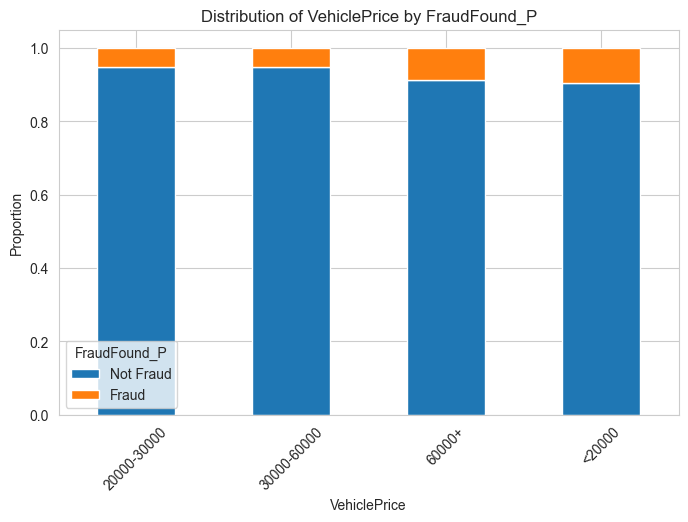

<Figure size 800x500 with 0 Axes>

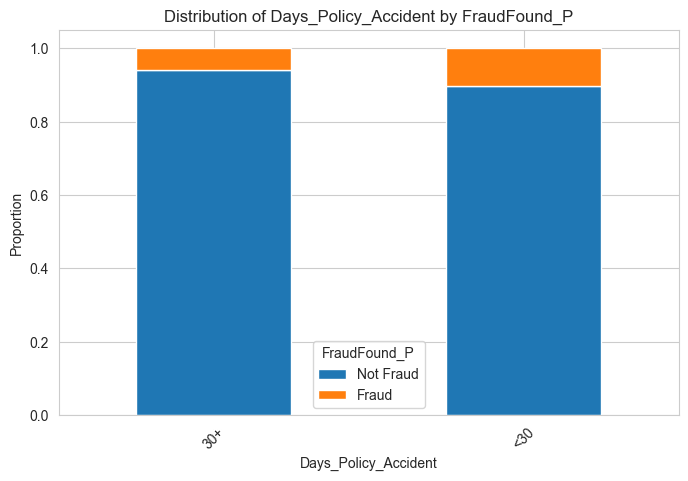

<Figure size 800x500 with 0 Axes>

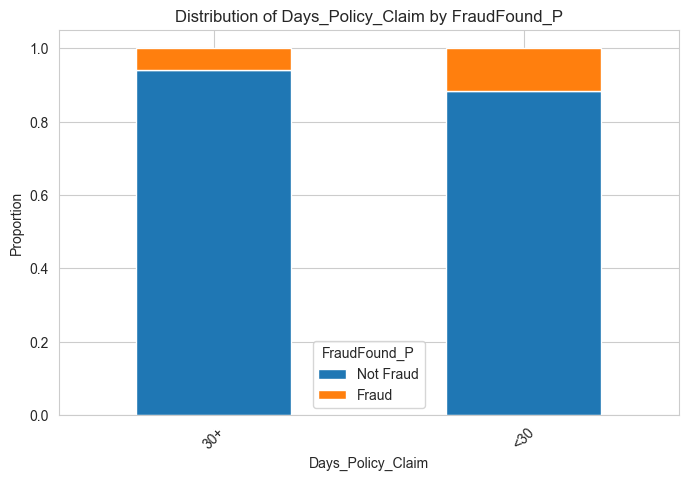

<Figure size 800x500 with 0 Axes>

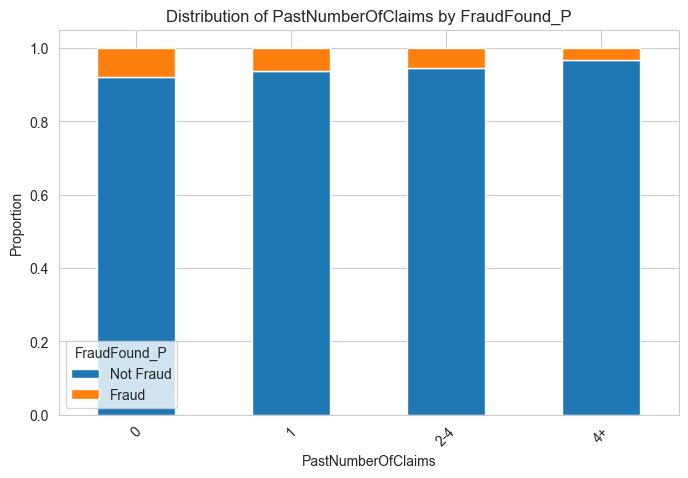

<Figure size 800x500 with 0 Axes>

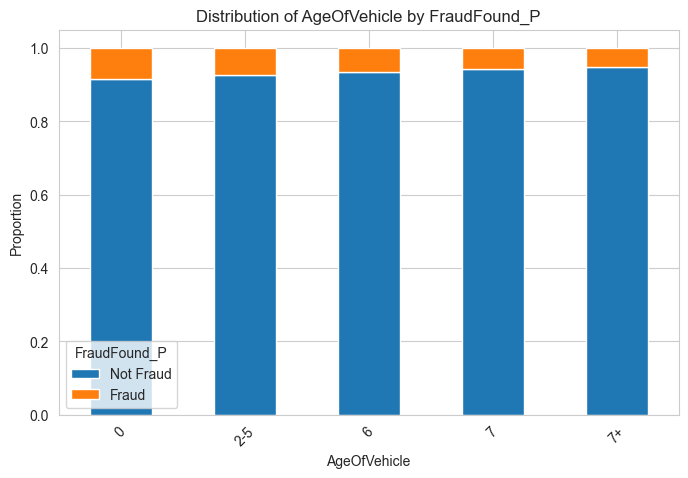

<Figure size 800x500 with 0 Axes>

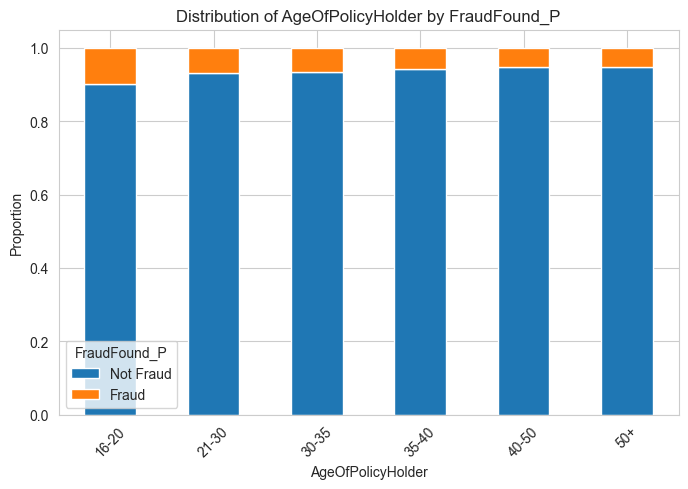

<Figure size 800x500 with 0 Axes>

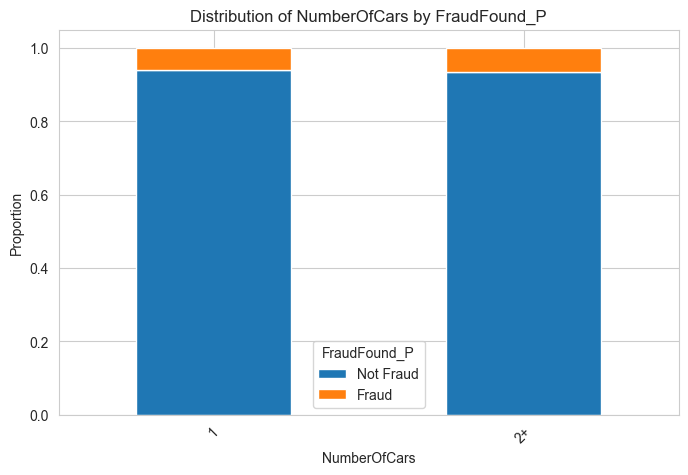

In [45]:
for col in ordinal_cols:
    plt.figure(figsize=(8, 5))
    df.groupby(col)["FraudFound_P"].value_counts(normalize=True).unstack().plot(kind="bar", stacked=True, figsize=(8, 5))
    plt.title(f"Distribution of {col} by FraudFound_P")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.legend(title="FraudFound_P", labels=["Not Fraud", "Fraud"])
    plt.xticks(rotation=45)
    plt.show()
    print("\n")
    print("="*90)
    print("\n")

### Time-Related Features

In [14]:
time_features = ["Month", "MonthClaimed", "DayOfWeek", "DayOfWeekClaimed", "WeekOfMonth", "WeekOfMonthClaimed"]
df[time_features].sample(5)

,Month,MonthClaimed,DayOfWeek,DayOfWeekClaimed,WeekOfMonth,WeekOfMonthClaimed
431,Jul,Aug,Friday,Monday,4,2
2910,Apr,Apr,Sunday,Tuesday,3,3
13896,Jan,Jan,Wednesday,Thursday,2,2
15293,Jan,Jan,Monday,Monday,4,4
4425,Jun,Jun,Monday,Tuesday,4,5


##### Changing `Month` and `MonthClaimed` Column

In [15]:
df["Month"] = df["Month"].map(
    {
        "Jan": 1,
        "Feb": 2,
        "Mar": 3,
        "Apr": 4,
        "May": 5,
        "Jun": 6,
        "Jul": 7,
        "Aug": 8,
        "Sep": 9,
        "Oct": 10,
        "Nov": 11,
        "Dec": 12,
    }
)

df["MonthClaimed"] = df["MonthClaimed"].map(
    {
        "Jan": 1,
        "Feb": 2,
        "Mar": 3,
        "Apr": 4,
        "May": 5,
        "Jun": 6,
        "Jul": 7,
        "Aug": 8,
        "Sep": 9,
        "Oct": 10,
        "Nov": 11,
        "Dec": 12,
    }
)

##### Changing `DayOfWeek` and `DayOfWeekClaimed` Column

In [16]:
df["DayOfWeek"] = df["DayOfWeek"].map(
    {
        "Monday": 1,
        "Tuesday": 2,
        "Wednesday": 3,
        "Thursday": 4,
        "Friday": 5,
        "Saturday": 6,
        "Sunday": 7,
    }
)

df["DayOfWeekClaimed"] = df["DayOfWeekClaimed"].map(
    {
        "Monday": 1,
        "Tuesday": 2,
        "Wednesday": 3,
        "Thursday": 4,
        "Friday": 5,
        "Saturday": 6,
        "Sunday": 7,
    }
)

In [17]:
df[time_features].sample(5)

,Month,MonthClaimed,DayOfWeek,DayOfWeekClaimed,WeekOfMonth,WeekOfMonthClaimed
4576,7,8.0,1,3.0,5,1
508,1,1.0,7,4.0,2,3
9654,11,11.0,6,7.0,3,3
11566,9,9.0,2,2.0,3,3
4228,6,6.0,5,3.0,1,2


##### Creating Time Delay Features

In [34]:
df["MonthDelay"] = (df["MonthClaimed"] - df["Month"]) % 12
df["DayDelay"] = (df["DayOfWeekClaimed"] - df["DayOfWeek"]) % 7
df["WeekDelay"] = (df["WeekOfMonthClaimed"] - df["WeekOfMonth"]) % 5

df["MonthDelay"] = df["MonthDelay"].astype("Int64")
df["DayDelay"] = df["DayDelay"].astype("Int64")
df["WeekDelay"] = df["WeekDelay"].astype("Int64")

In [35]:
df[["MonthDelay", "DayDelay", "WeekDelay"]].sample(5)

,MonthDelay,DayDelay,WeekDelay
9762,0,5,1
10843,2,0,3
11446,1,3,1
14476,0,6,1
10029,0,2,1


Dropping Old features

In [36]:
df.drop(columns=time_features, inplace=True)

##### Plotting These Time-related features

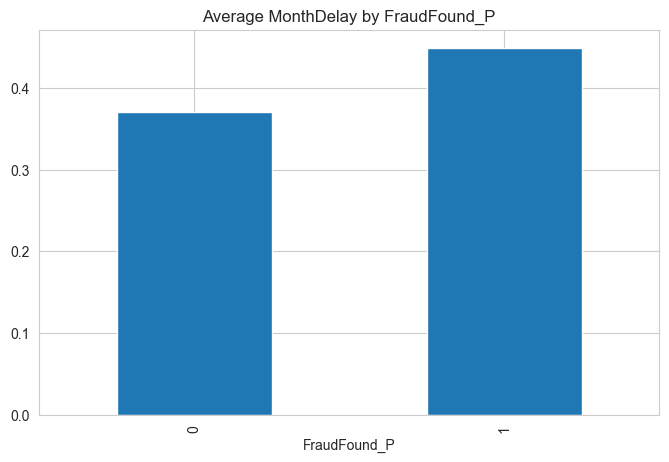

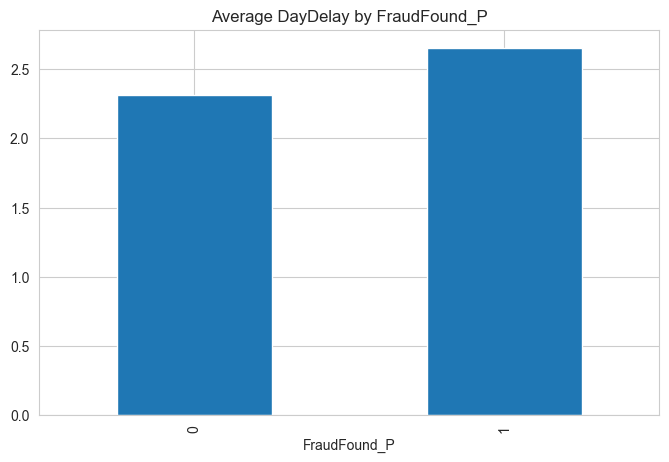

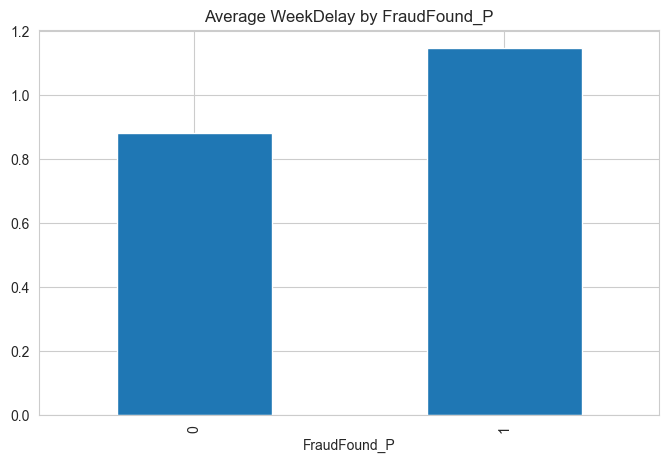

In [72]:
time_delay_cols = ["MonthDelay", "DayDelay", "WeekDelay"]

for col in time_delay_cols:
    df.groupby("FraudFound_P")[col].mean().plot(kind="bar", figsize=(8, 5))
    plt.title(f"Average {col} by FraudFound_P")
    plt.show()
    print("\n")
    print("="*90)
    print("\n")

### Remaining Categorical Columns

In [53]:
cols_left = df.select_dtypes(include="object").columns.drop(cols_to_check).tolist()
cols_left

['Make',
 'AccidentArea',
 'Sex',
 'MaritalStatus',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'BasePolicy']

In [54]:
for col in cols_left:
    print(f"======{col}======")
    print(df[col].value_counts())
    print("\n")

======Make======
Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64


======AccidentArea======
AccidentArea
Urban    13822
Rural     1598
Name: count, dtype: int64


======Sex======
Sex
Male      13000
Female     2420
Name: count, dtype: int64


======MaritalStatus======
MaritalStatus
Married     10625
Single       4684
Divorced       76
Widow          35
Name: count, dtype: int64


======Fault======
Fault
Policy Holder    11230
Third Party       4190
Name: count, dtype: int64


======PolicyType======
PolicyType
Sedan - Collision       5584
Sedan - Liability       4987
Sedan - All Perils      4087
Sport - Collision        348
Utility - All Perils     340
Utility - Colli

From here we'll: 

- Drop `Make` due to less entries

- Change categories of `MaritalStatus` due to less entries

- Drop `PolicyType` due to less entries

- Combine `WitnessPresent` due to less entries

##### Dropping Columns

In [55]:
df.drop(columns = ["Make", "PolicyType"], inplace=True)

##### Adjusting `MaritalStatus` Feature

In [68]:
df["MaritalStatus"] = df["MaritalStatus"].map(
    {
        "Single": "Not Married",
        "Divorced": "Not Married",
        "Widow": "Not Married",
        "Married": "Married"
    }
)

##### Combine `WitnessPresent` w/ `PoliceReportFiled`

In [58]:
df["WitnessPresent"].value_counts()

WitnessPresent
No     15333
Yes       87
Name: count, dtype: int64

In [59]:
df["PoliceReportFiled"].value_counts()

PoliceReportFiled
No     14992
Yes      428
Name: count, dtype: int64

In [60]:
df["NoWitnessNoPoliceReport"] = np.where((df["WitnessPresent"] == "No") & (df["PoliceReportFiled"] == "No"), "Yes", "No")

In [62]:
df.groupby("NoWitnessNoPoliceReport")["FraudFound_P"].value_counts()

NoWitnessNoPoliceReport  FraudFound_P
No                       0                 457
                         1                  18
Yes                      0               14040
                         1                 905
Name: count, dtype: int64

In [63]:
df.drop("WitnessPresent", axis=1, inplace=True)

##### Plotting These Remaining Columns

In [66]:
cols_left

['Make',
 'AccidentArea',
 'Sex',
 'MaritalStatus',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'BasePolicy']

<Figure size 800x500 with 0 Axes>

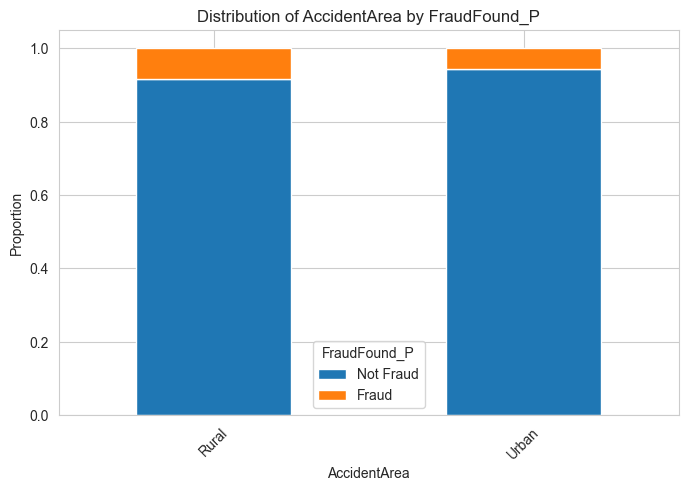

<Figure size 800x500 with 0 Axes>

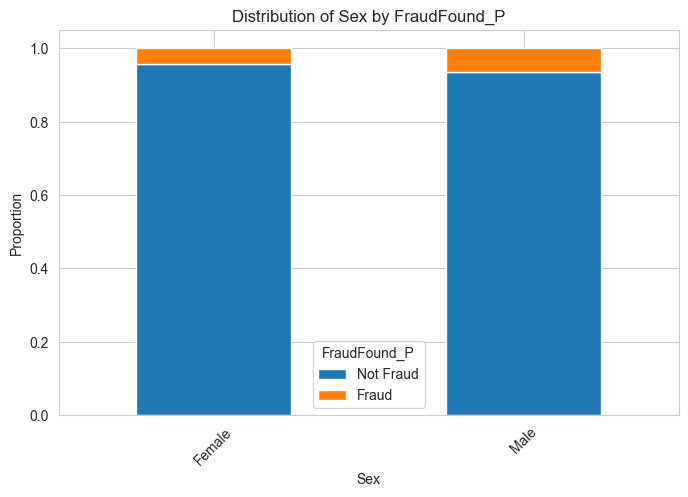

<Figure size 800x500 with 0 Axes>

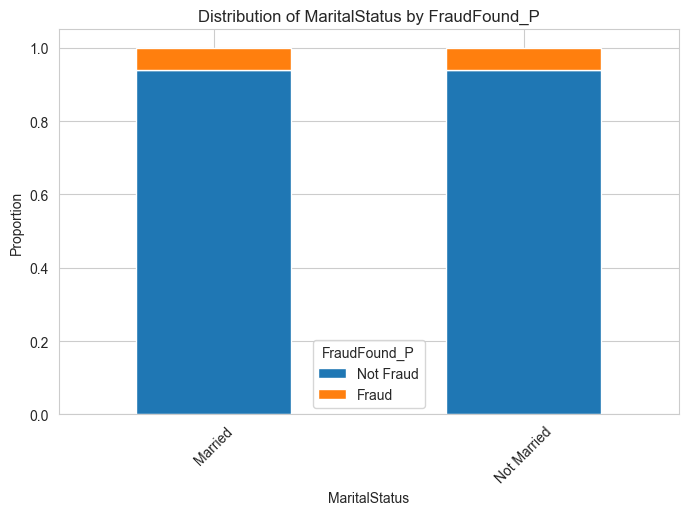

<Figure size 800x500 with 0 Axes>

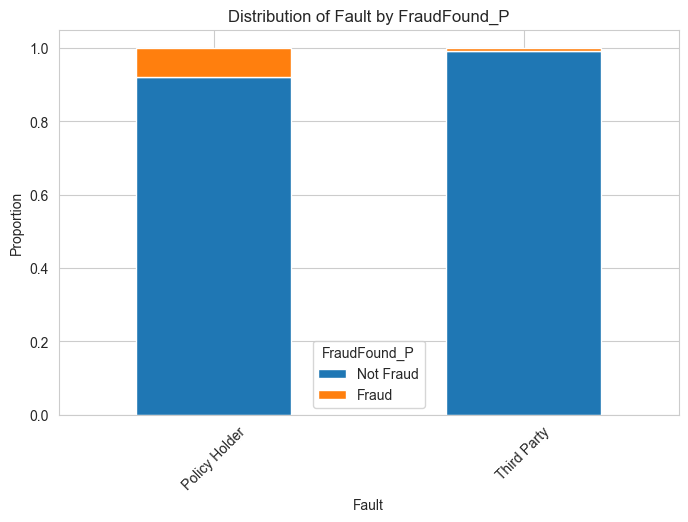

<Figure size 800x500 with 0 Axes>

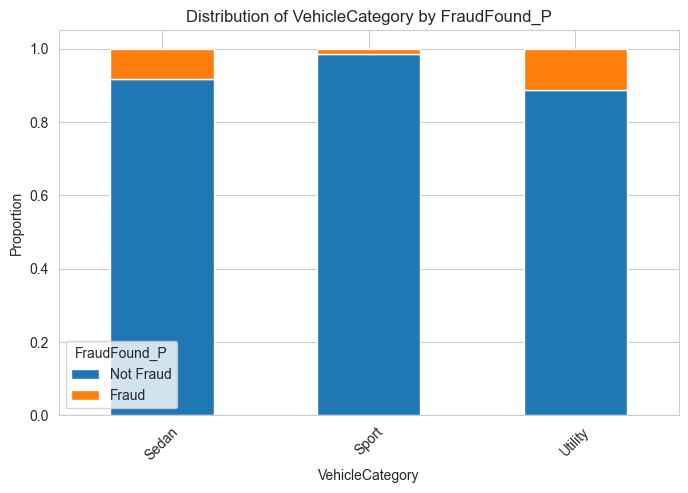

<Figure size 800x500 with 0 Axes>

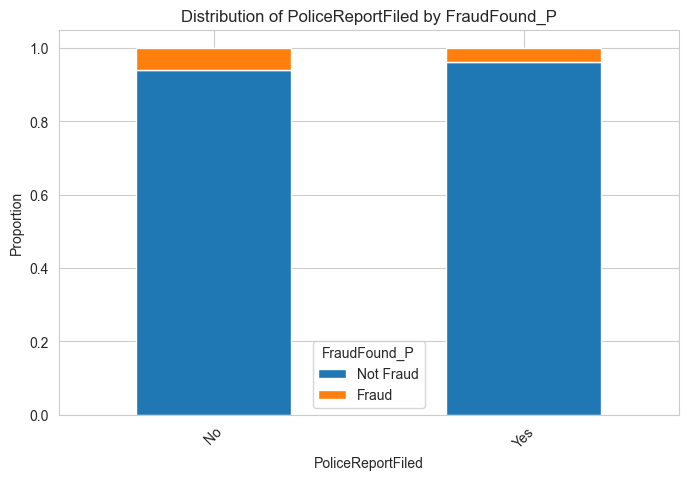

<Figure size 800x500 with 0 Axes>

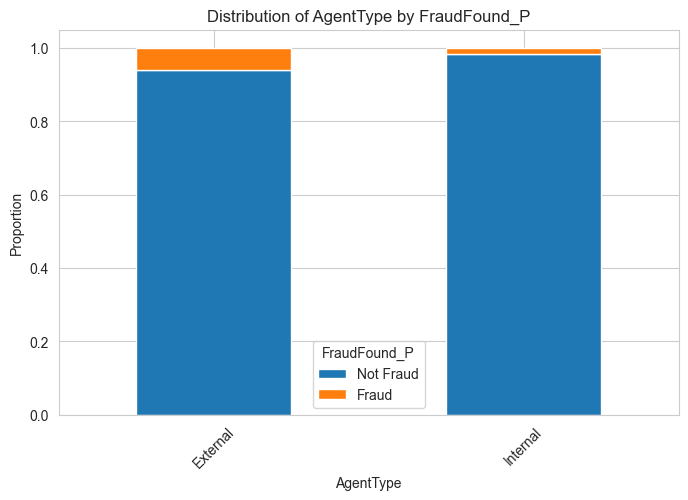

<Figure size 800x500 with 0 Axes>

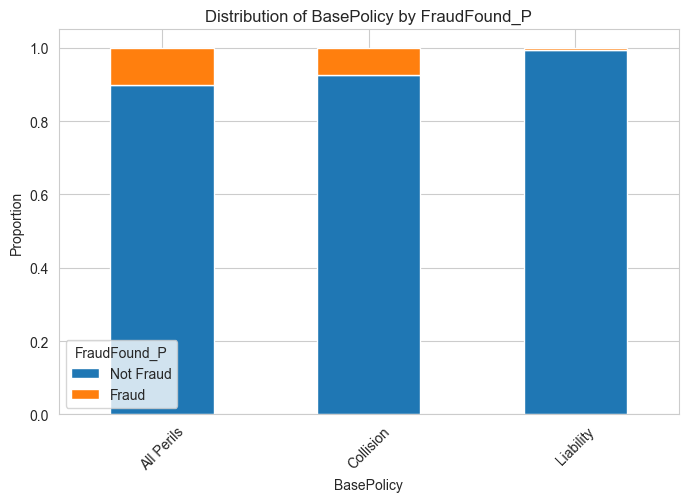

In [69]:
for col in ['AccidentArea','Sex','MaritalStatus','Fault','VehicleCategory','PoliceReportFiled','AgentType','BasePolicy']:
    plt.figure(figsize=(8, 5))
    df.groupby(col)["FraudFound_P"].value_counts(normalize=True).unstack().plot(kind="bar", stacked=True, figsize=(8, 5))
    plt.title(f"Distribution of {col} by FraudFound_P")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.legend(title="FraudFound_P", labels=["Not Fraud", "Fraud"])
    plt.xticks(rotation=45)
    plt.show()
    print("\n")
    print("="*90)
    print("\n")

### Numerical Columns

In [74]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop("FraudFound_P").tolist()
num_cols

['Age',
 'PolicyNumber',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Year',
 'MonthDelay',
 'DayDelay',
 'WeekDelay']

We're gonna drop `PolicyNumber` and `RepNumber` as they just represent IDs or serial no. along with `Year` which has no use in this project

##### Dropping Columns

In [76]:
df.drop(columns=["PolicyNumber", "RepNumber", "Year"], inplace=True)

##### Checking Remaining Columns

In [77]:
for col in ["Age", "Deductible", "DriverRating"]:
    print(f"======{col}======")
    print("Max", df[col].max())
    print("Min", df[col].min())
    print("Mean", df[col].mean())
    print("\n")

======Age======
Max 80
Min 0
Mean 39.855706874189366


======Deductible======
Max 700
Min 300
Mean 407.70428015564204


======DriverRating======
Max 4
Min 1
Mean 2.4878080415045396




##### Checking Faulty Ages

In [81]:
df["Age"][df["Age"] < 16].value_counts()

Age
0    320
Name: count, dtype: int64

We're gonna remove these faulty values

In [82]:
df.drop(df[df["Age"] < 16].index, inplace=True)

In [84]:
df["Age"].min()

np.int64(16)

### Creating Flags

In [85]:
df.columns

Index(['AccidentArea', 'Sex', 'MaritalStatus', 'Age', 'Fault',
       'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'Deductible',
       'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'PoliceReportFiled', 'AgentType', 'NumberOfSuppliments',
       'AddressChange_Claim', 'NumberOfCars', 'BasePolicy', 'MonthDelay',
       'DayDelay', 'WeekDelay', 'NoWitnessNoPoliceReport'],
      dtype='str')

##### Flags To Check:

1. Less age but expensive vehicle

P.S. checked multiple which were not feasible

##### Less age, Expensive Vehicle

In [92]:
df["Age"].value_counts()

Age
30    596
33    574
34    573
35    569
28    560
     ... 
20     28
70     27
79     20
16      9
17      6
Name: count, Length: 65, dtype: int64

In [87]:
df["VehiclePrice"].value_counts()

VehiclePrice
20000-30000    8079
30000-60000    3993
60000+         1933
<20000         1095
Name: count, dtype: int64

In [99]:
df[(df["Age"] < 20) & (df["VehiclePrice"] == "60000+")]["FraudFound_P"].value_counts()

FraudFound_P
0    23
1    10
Name: count, dtype: int64

In [111]:
df["LessAgeExpensiveVehicle"] = np.where((df["Age"] < 20) & (df["VehiclePrice"] == "60000+"), 1, 0)

In [113]:
df["LessAgeExpensiveVehicle"].value_counts()

LessAgeExpensiveVehicle
0    15067
1       33
Name: count, dtype: int64

In [122]:
df["WeekDelay"].value_counts()

WeekDelay
0    6968
1    4845
2    1801
3     937
4     549
Name: count, dtype: Int64

#### Exporting The new dataset

In [126]:
df.columns

Index(['AccidentArea', 'Sex', 'MaritalStatus', 'Age', 'Fault',
       'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'Deductible',
       'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'PoliceReportFiled', 'AgentType', 'NumberOfSuppliments',
       'AddressChange_Claim', 'NumberOfCars', 'BasePolicy', 'MonthDelay',
       'DayDelay', 'WeekDelay', 'NoWitnessNoPoliceReport',
       'LessAgeExpensiveVehicle'],
      dtype='str')

In [127]:
df.info()

<class 'pandas.DataFrame'>
Index: 15100 entries, 0 to 15419
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   AccidentArea             15100 non-null  str  
 1   Sex                      15100 non-null  str  
 2   MaritalStatus            15100 non-null  str  
 3   Age                      15100 non-null  int64
 4   Fault                    15100 non-null  str  
 5   VehicleCategory          15100 non-null  str  
 6   VehiclePrice             15100 non-null  str  
 7   FraudFound_P             15100 non-null  int64
 8   Deductible               15100 non-null  int64
 9   DriverRating             15100 non-null  int64
 10  Days_Policy_Accident     15100 non-null  str  
 11  Days_Policy_Claim        15100 non-null  str  
 12  PastNumberOfClaims       15100 non-null  str  
 13  AgeOfVehicle             15100 non-null  str  
 14  AgeOfPolicyHolder        15100 non-null  str  
 15  PoliceReportFiled 

Now exporting

In [128]:
df.to_csv("new_data.csv", index=False)

### Insights From Notebook:

##### New Features Created:

- `MonthDelay`: Difference between Month of incident and Month of claim

- `DayDelay`: Difference between Day of incident and Day of claim

- `WeekDelay`: Difference between Week of incident and Week of claim

- `NoWitnessNoPoliceReport`: If there was no witness and no police report filed

##### Columns Dropped:

- `Month` and `MonthClaimed`

- `WeekOfMonth` and `WeekOfMonthClaimed`

- `DayOfWeek` and `DayOfWeekClaimed`

- `PolicyType`

- `WitnessPresent`

##### Important Points:

- `ordinal_cols`: Columns to apply *LabelEncoding*

- `time_delay_cols`: Time-related columns
